# 03 — Exploratory Data Analysis (EDA)

This notebook explores the validated dataset (`data/processed/cleaned_dataset.csv`) with the
project's actual features in mind: engagement prediction, platform comparison, posting-time
recommendation, content-type recommendation, and hashtag analysis. Every chart here is meant
to answer a specific question relevant to those features — we avoid decorative charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Month'] = df['Timestamp'].dt.month_name()
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns (+ derived Month).")


Loaded 3025 rows, 23 columns (+ derived Month).


## A. Platform Performance
Directly supports **Feature 2 (Platform Comparison)**: how do TikTok, Instagram, and Facebook
differ in typical engagement?

In [2]:
platform_stats = df.groupby('Platform')['Engagement_Rate'].agg(
    post_count='count', mean_engagement='mean', median_engagement='median', std_engagement='std'
).round(2).sort_values('median_engagement', ascending=False)
platform_stats


,post_count,mean_engagement,median_engagement,std_engagement
Platform,,,,
TikTok,758,41.83,11.02,162.92
Instagram,1283,8.12,2.12,44.82
Facebook,984,7.17,2.00,36.11


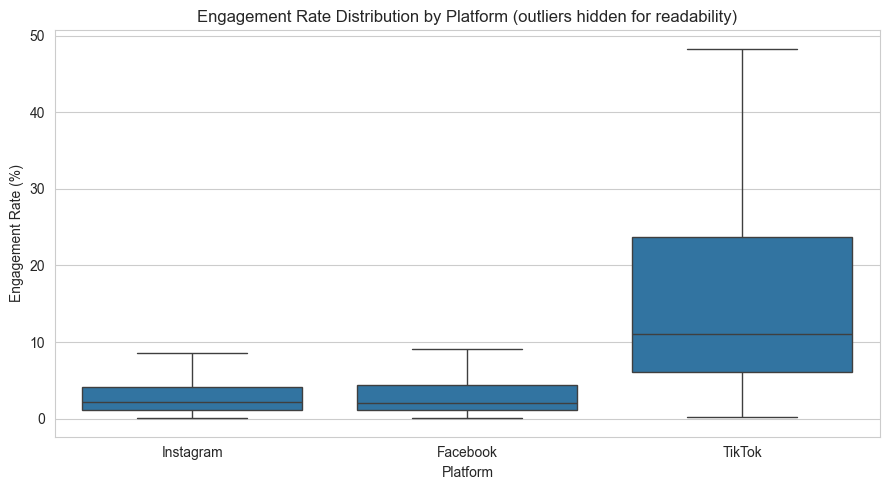

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Platform', y='Engagement_Rate', ax=ax, showfliers=False)
ax.set_title('Engagement Rate Distribution by Platform (outliers hidden for readability)')
ax.set_ylabel('Engagement Rate (%)')
plt.tight_layout()
plt.show()


**What this means for the app:** because we use the median (robust to the extreme
outliers we saw in notebook 01) rather than the mean, we get a fairer picture of "typical"
performance per platform. This directly powers the Platform Comparison feature — the model
predicts engagement level per platform for the same content.

## B. Category / Topic Performance
Supports **Feature 4 (Content Idea Recommendation)** — which topics tend to perform best, and does that change by platform?

Category
Travel           3.94
Sports           3.50
Fitness          3.22
Education        3.20
Technology       3.18
Entertainment    3.13
Food             3.12
Lifestyle        2.87
Health           2.68
Business         2.66
Fashion          2.66
Gaming           2.61
Name: Engagement_Rate, dtype: float64


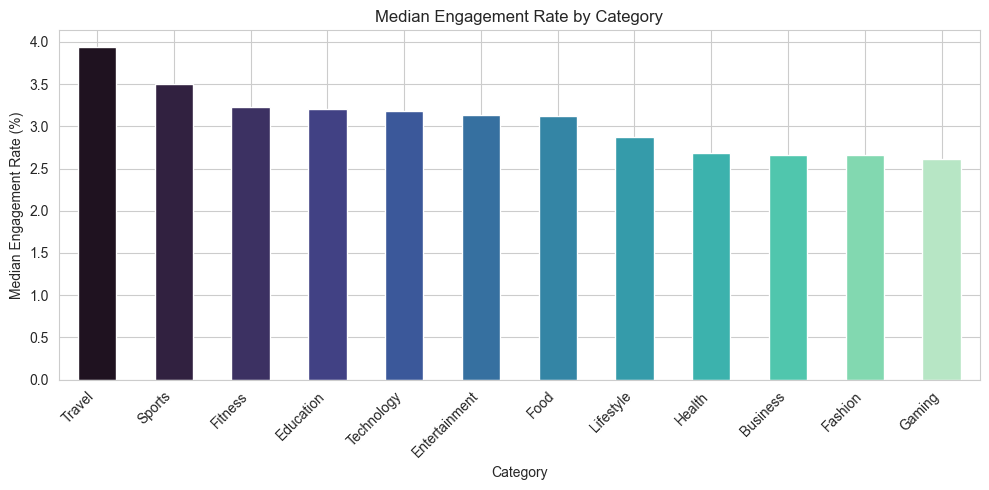

In [4]:
category_stats = df.groupby('Category')['Engagement_Rate'].median().sort_values(ascending=False)
print(category_stats.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
category_stats.plot(kind='bar', ax=ax, color=sns.color_palette('mako', len(category_stats)))
ax.set_title('Median Engagement Rate by Category')
ax.set_ylabel('Median Engagement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Platform,Facebook,Instagram,TikTok
Category,,,
Business,1.72,1.94,10.37
Education,1.72,2.09,10.91
Entertainment,1.98,2.21,11.72
Fashion,2.03,1.95,12.46
Fitness,1.94,2.14,10.52
Food,1.94,1.95,10.85
Gaming,1.48,2.24,10.92
Health,1.86,1.88,9.34
Lifestyle,2.52,1.87,12.30


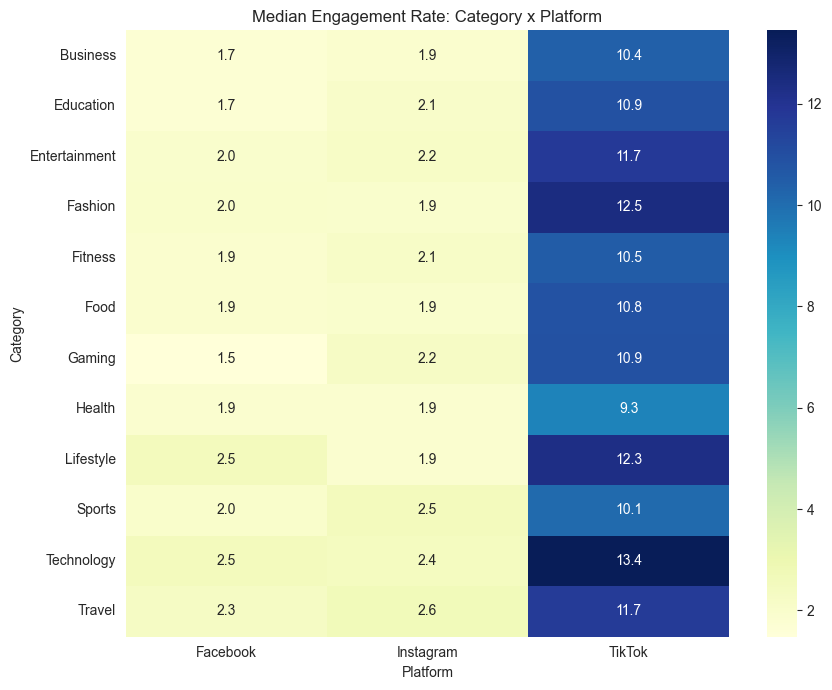

In [5]:
pivot_cat_platform = df.pivot_table(index='Category', columns='Platform',
                                     values='Engagement_Rate', aggfunc='median').round(2)
display(pivot_cat_platform)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot_cat_platform, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Median Engagement Rate: Category x Platform')
plt.tight_layout()
plt.show()


**What this means for the app:** the best-performing category is not the same across platforms. This heatmap is exactly the kind of historical lookup the Content Idea / Content Type Recommendation features need.

## C. Content Type Performance
Supports **Feature 4 (Content Type Recommendation)**.

Content_Type
Duet        11.54
Stitch      10.68
Video        4.56
Post         2.46
Carousel     2.25
Photo        2.12
Reel         2.04
Story        2.02
Live         1.76
Name: Engagement_Rate, dtype: float64


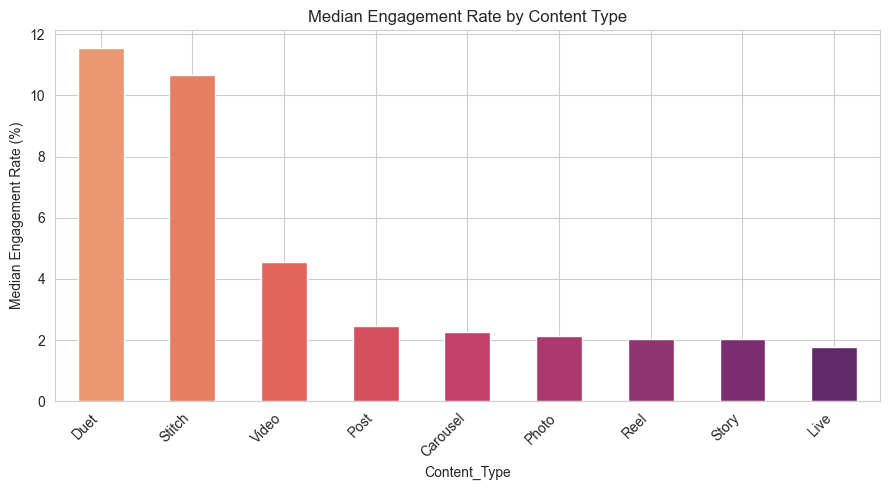

In [6]:
content_type_stats = df.groupby('Content_Type')['Engagement_Rate'].median().sort_values(ascending=False)
print(content_type_stats.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
content_type_stats.plot(kind='bar', ax=ax, color=sns.color_palette('flare', len(content_type_stats)))
ax.set_title('Median Engagement Rate by Content Type')
ax.set_ylabel('Median Engagement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [7]:
# Content type performance WITHIN each platform (since content types are mostly platform-specific)
for platform in df['Platform'].unique():
    sub = df[df['Platform'] == platform]
    ranked = sub.groupby('Content_Type')['Engagement_Rate'].median().sort_values(ascending=False)
    print(f"--- {platform} ---")
    print(ranked.round(2))
    print()


--- Instagram ---
Content_Type
Carousel    2.25
Photo       2.12
Story       2.12
Reel        2.04
Name: Engagement_Rate, dtype: float64

--- Facebook ---
Content_Type
Post     2.46
Video    2.01
Story    1.84
Live     1.76
Name: Engagement_Rate, dtype: float64

--- TikTok ---
Content_Type
Duet      11.54
Stitch    10.68
Video     10.50
Name: Engagement_Rate, dtype: float64



In [8]:
# Content type + category combined (top 15 combos by post count, to keep it meaningful)
combo = df.groupby(['Platform', 'Content_Type', 'Category'])['Engagement_Rate'].agg(['median', 'count'])
combo = combo[combo['count'] >= 10].sort_values('median', ascending=False)
combo.head(15).round(2)


median  count
Platform Content_Type Category                    
TikTok   Stitch       Technology      19.55     28
         Video        Lifestyle       16.54     16
         Duet         Fashion         16.52     16
         Stitch       Education       14.48     25
         Video        Travel          13.73     18
                      Technology      13.44     21
                      Entertainment   13.32     23
         Duet         Sports          13.02     18
                      Fitness         12.62     26
                      Health          12.58     21
                      Entertainment   12.31     22
         Video        Fashion         12.16     29
                      Gaming          11.97     21
         Duet         Lifestyle       11.95     21
         Stitch       Travel          11.68     31

**What this means for the app:** ranking content type by median engagement, computed *within* each platform, is exactly the statistical lookup logic described in the project scope for the Content Type Recommendation feature (no separate ML model needed).

## D. Time Analysis
Supports **Feature 3 (Best Posting Time Recommendation)**. The dataset has a real `Hour_of_Day`
(0-23) and `Day_of_Week` derived from an actual `Timestamp`, so hourly posting-time analysis
**is** supported here (unlike many portfolio datasets that only have a vague "morning/evening" bucket).

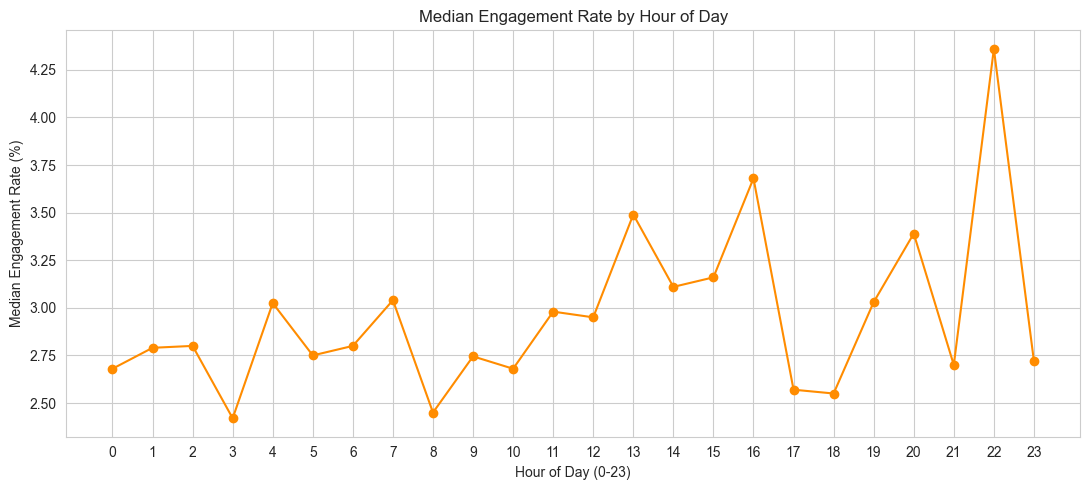

Top 5 hours by median engagement:
Hour_of_Day
22    4.36
16    3.68
13    3.49
20    3.39
15    3.16
Name: Engagement_Rate, dtype: float64


In [9]:
hourly = df.groupby('Hour_of_Day')['Engagement_Rate'].median()

fig, ax = plt.subplots(figsize=(11, 5))
hourly.plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title('Median Engagement Rate by Hour of Day')
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Median Engagement Rate (%)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print("Top 5 hours by median engagement:")
print(hourly.sort_values(ascending=False).head(5).round(2))


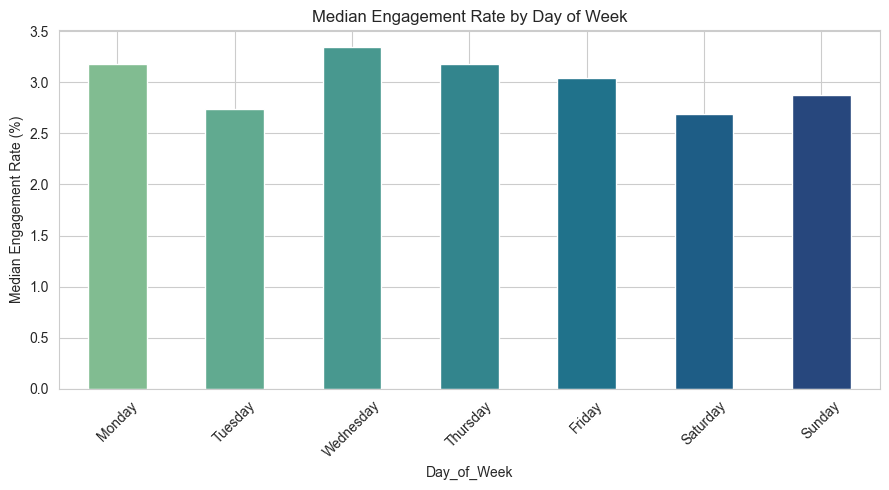

In [10]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = df.groupby('Day_of_Week')['Engagement_Rate'].median().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
dow_stats.plot(kind='bar', ax=ax, color=sns.color_palette('crest', 7))
ax.set_title('Median Engagement Rate by Day of Week')
ax.set_ylabel('Median Engagement Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


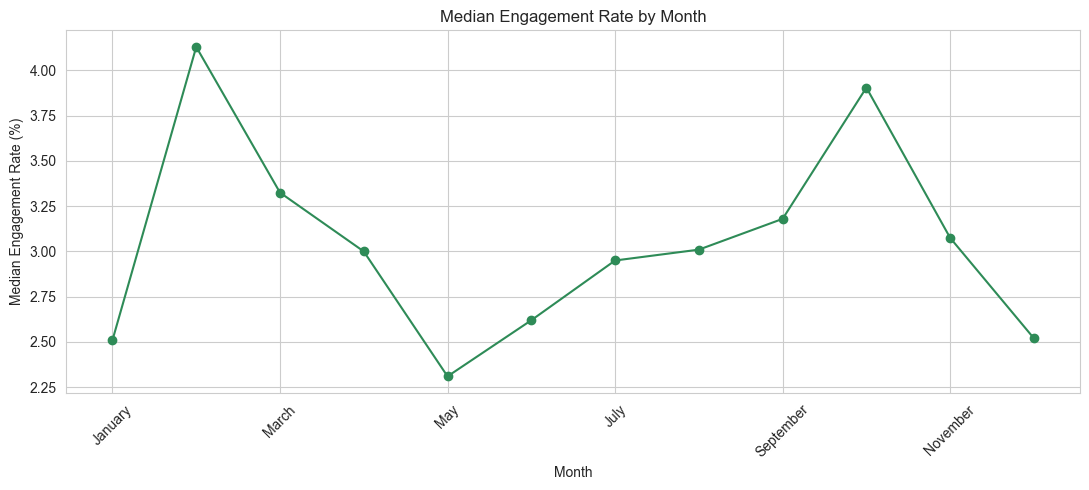

In [11]:
month_order = ['January','February','March','April','May','June','July','August',
                'September','October','November','December']
month_stats = df.groupby('Month')['Engagement_Rate'].median().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 5))
month_stats.plot(kind='line', marker='o', ax=ax, color='seagreen')
ax.set_title('Median Engagement Rate by Month')
ax.set_ylabel('Median Engagement Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
# Best hour PER PLATFORM - this is the granular lookup the app actually needs
best_hour_per_platform = df.groupby(['Platform', 'Hour_of_Day'])['Engagement_Rate'].median().reset_index()
top3_per_platform = (best_hour_per_platform.sort_values('Engagement_Rate', ascending=False)
                      .groupby('Platform').head(3).sort_values(['Platform', 'Engagement_Rate'], ascending=[True, False]))
top3_per_platform


,Platform,Hour_of_Day,Engagement_Rate
11,Facebook,11,3.310
13,Facebook,13,3.010
16,Facebook,16,2.740
46,Instagram,22,3.070
44,Instagram,20,2.850
37,Instagram,13,2.755
68,TikTok,20,16.375
63,TikTok,15,15.790
50,TikTok,2,15.725


**What this means for the app:** the dataset supports hourly posting-time recommendations, and they should be computed **per platform**, since the best hour is not identical across TikTok/Instagram/Facebook.

## E. Hashtag Analysis
Supports **Feature 5 (Caption & Hashtag Analysis)**. Note: we only have `Hashtag_Count`
(a number), not the actual hashtags used — so this section can only analyze *how many*
hashtags correlate with engagement, not *which* hashtags work best.

Hashtag count summary:
count    3025.000000
mean       14.532893
std         8.668669
min         0.000000
25%         7.000000
50%        15.000000
75%        22.000000
max        29.000000
Name: Hashtag_Count, dtype: float64


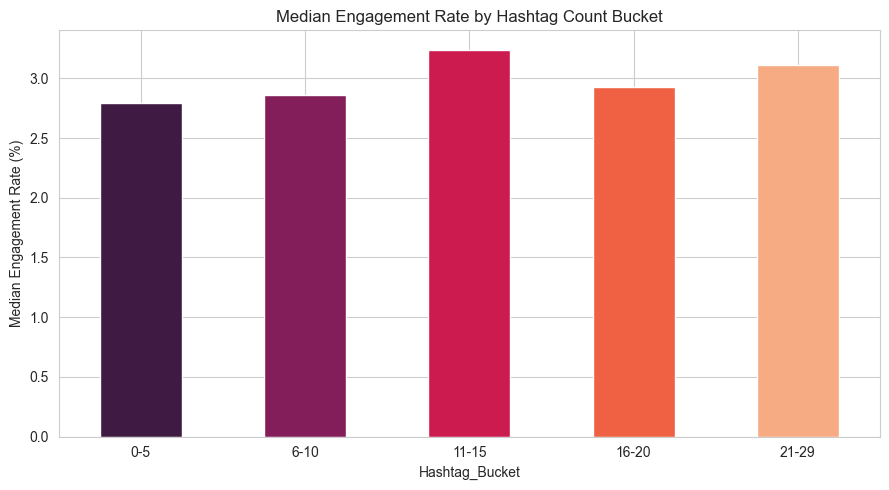

In [13]:
print("Hashtag count summary:")
print(df['Hashtag_Count'].describe())

# Bin hashtag count into ranges for a cleaner relationship view
df['Hashtag_Bucket'] = pd.cut(df['Hashtag_Count'], bins=[-1, 5, 10, 15, 20, 30],
                               labels=['0-5', '6-10', '11-15', '16-20', '21-29'])
hashtag_eng = df.groupby('Hashtag_Bucket', observed=True)['Engagement_Rate'].median()

fig, ax = plt.subplots(figsize=(9, 5))
hashtag_eng.plot(kind='bar', ax=ax, color=sns.color_palette('rocket', len(hashtag_eng)))
ax.set_title('Median Engagement Rate by Hashtag Count Bucket')
ax.set_ylabel('Median Engagement Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Correlation between Hashtag_Count and Engagement_Rate: -0.006


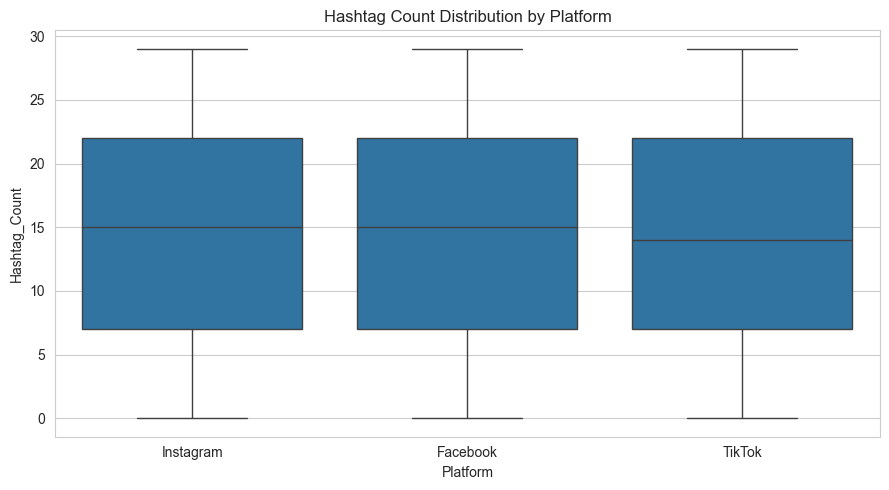

Platform
Facebook     15.0
Instagram    15.0
TikTok       14.0
Name: Hashtag_Count, dtype: float64


In [14]:
corr = df['Hashtag_Count'].corr(df['Engagement_Rate'])
print(f"Correlation between Hashtag_Count and Engagement_Rate: {corr:.3f}")

# Hashtag count patterns by platform
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Platform', y='Hashtag_Count', ax=ax)
ax.set_title('Hashtag Count Distribution by Platform')
plt.tight_layout()
plt.show()
print(df.groupby('Platform')['Hashtag_Count'].median())


In [15]:
# Hashtag count patterns by topic
hashtag_by_cat = df.groupby('Category')['Hashtag_Count'].median().sort_values(ascending=False)
hashtag_by_cat


Category
Health           16.0
Business         15.5
Entertainment    15.0
Education        15.0
Travel           15.0
Gaming           15.0
Sports           15.0
Fashion          14.0
Fitness          14.0
Food             14.0
Lifestyle        14.0
Technology       12.0
Name: Hashtag_Count, dtype: float64

**What this means for the app:** hashtag *count* alone has only a weak relationship with
engagement. Since we don't have the actual hashtag text, the Caption & Hashtag Analysis feature
cannot be trained on historical hashtag performance — it will need to use NLP/rule-based/LLM
methods on the user's *typed* caption and hashtags directly, not a trained ranking model.
This is logged in **Dataset Limitations**.

## F. Caption / Text Analysis
The project asks for this **only if actual caption/text data exists**. We confirmed in
notebook 01 that there is no caption text column — only `Content_Length` (a numeric length).
We analyze what we actually have.

Actual caption/text column present: False
THIS FEATURE IS NOT AVAILABLE IN THE DATASET (real caption text, so no word count/sentiment-from-text is derivable).

We DO have Content_Length (numeric) and a pre-labeled Sentiment column, so we analyze those instead.

Correlation between Content_Length and Engagement_Rate: -0.062


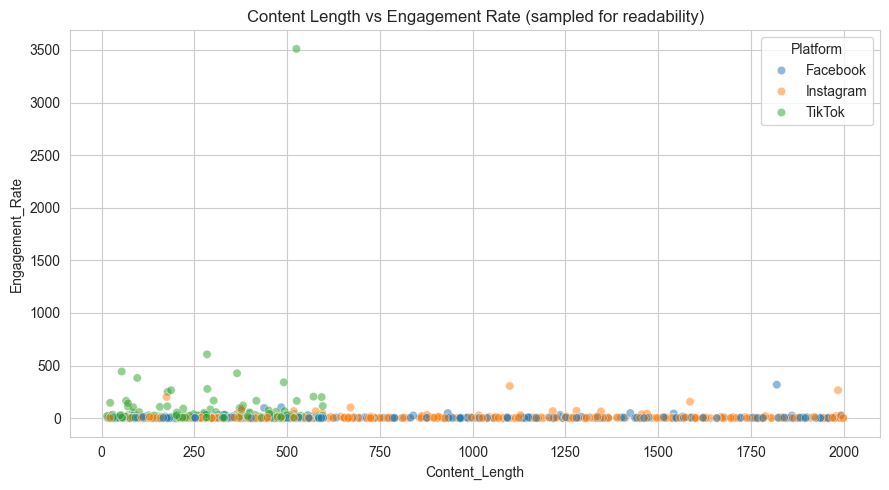

In [16]:
print("Actual caption/text column present: False")
print("THIS FEATURE IS NOT AVAILABLE IN THE DATASET (real caption text, so no word count/sentiment-from-text is derivable).")
print()
print("We DO have Content_Length (numeric) and a pre-labeled Sentiment column, so we analyze those instead.")

corr_length = df['Content_Length'].corr(df['Engagement_Rate'])
print(f"\nCorrelation between Content_Length and Engagement_Rate: {corr_length:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df.sample(min(1000, len(df)), random_state=42),
                 x='Content_Length', y='Engagement_Rate', hue='Platform', alpha=0.5, ax=ax)
ax.set_title('Content Length vs Engagement Rate (sampled for readability)')
plt.tight_layout()
plt.show()


Sentiment
Negative    3.07
Neutral     3.04
Positive    2.98
Name: Engagement_Rate, dtype: float64


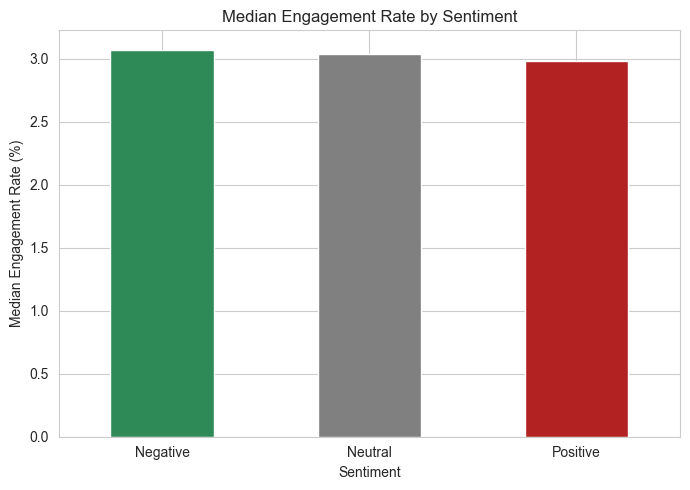

In [17]:
sentiment_stats = df.groupby('Sentiment')['Engagement_Rate'].median().sort_values(ascending=False)
print(sentiment_stats.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
sentiment_stats.plot(kind='bar', ax=ax, color=['seagreen', 'gray', 'firebrick'])
ax.set_title('Median Engagement Rate by Sentiment')
ax.set_ylabel('Median Engagement Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## G. Engagement Distribution
We already looked at this briefly in notebook 01; here we go deeper because this
distribution directly determines how we define the Low/Medium/High target in notebook 04.

In [18]:
from scipy import stats as sp_stats
er = df['Engagement_Rate']
print("Mean:", round(er.mean(), 2))
print("Median:", round(er.median(), 2))
print("Std:", round(er.std(), 2))
print("Skewness:", round(er.skew(), 2))
print("Min / Max:", er.min(), '/', er.max())

q1, q3 = er.quantile(0.25), er.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_outliers = (er > upper_fence).sum()
print(f"\nIQR outlier fence (upper): {upper_fence:.2f}")
print(f"Rows above IQR fence: {n_outliers} ({n_outliers/len(df):.1%} of data)")
print(f"Dataset's own Flag_Engagement_Rate_Outlier column flags: {df['Flag_Engagement_Rate_Outlier'].sum()} rows")


Mean: 16.26
Median: 3.01
Std: 90.21
Skewness: 23.37
Min / Max: 0.06 / 3510.46

IQR outlier fence (upper): 19.17
Rows above IQR fence: 354 (11.7% of data)
Dataset's own Flag_Engagement_Rate_Outlier column flags: 474 rows


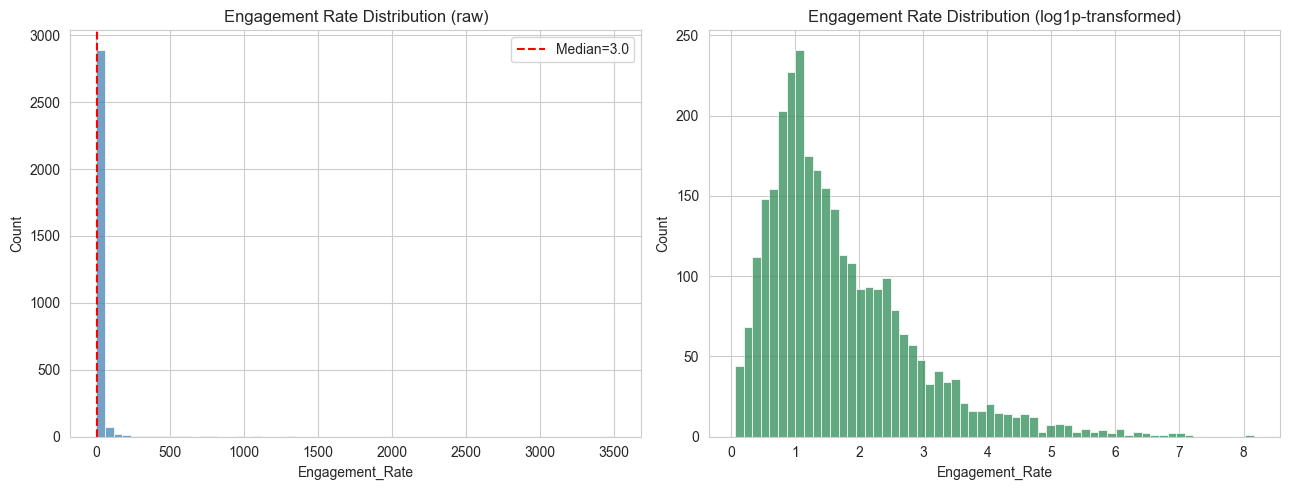

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(er, bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Engagement Rate Distribution (raw)')
axes[0].axvline(er.median(), color='red', linestyle='--', label=f'Median={er.median():.1f}')
axes[0].legend()

sns.histplot(np.log1p(er), bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('Engagement Rate Distribution (log1p-transformed)')
plt.tight_layout()
plt.show()


**What this means for the app:** `Engagement_Rate` is strongly right-skewed
(skewness far above 1) with a meaningful cluster of extreme outliers (matching the dataset's
own `Flag_Engagement_Rate_Outlier` column). This is exactly why we should NOT use fixed,
arbitrary thresholds (like "Low = 0-2%, High = 10%+") for the Low/Medium/High target —
we need a **quantile-based** approach so each class is well represented, which we implement
in notebook 04.

## EDA Summary — Key Findings

1. **Platform**: Median engagement differs meaningfully by platform; comparisons should use
   median, not mean, because of extreme outliers.
2. **Category**: Best-performing category is platform-dependent — supports a per-platform
   lookup table for content ideas, not a single global ranking.
3. **Content Type**: Best content type is also platform-dependent (naturally, since content
   types are mostly platform-specific formats).
4. **Time**: Real, granular hour-of-day and day-of-week data exists and shows measurable
   variation — hourly posting-time recommendations ARE supported, and should be computed
   per platform.
5. **Hashtags**: We only have hashtag *count*, not hashtag *text*. Count alone is weakly
   correlated with engagement — the Hashtag Analysis feature cannot be trained on which
   specific hashtags work.
6. **Captions**: No real caption text exists. We only have `Content_Length` (weak
   relationship with engagement) and a pre-existing `Sentiment` label. Caption improvement
   cannot be trained from historical text in this dataset.
7. **Engagement distribution**: Heavily right-skewed with real outliers — this directly
   informs a quantile-based (not arbitrary) target definition in the next notebook.

Next: `04_feature_engineering.ipynb`.